# Installation
Open Terminal and type 2 lines to install
+ pip install matplotlib
+ pip install seaborn
+ pip install ydata-profiling
+ pip install ipywidgets

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Module from lecture

In [ ]:
ydata = ProfileReport(abalone_df, title = 'Abalone')
ydata.to_notebook_iframe()

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


# Module from youtube

In [7]:
abalone_df = pd.read_csv('abalone.csv')
abalone_df.head() # Shows the first five samples

,Type,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [8]:
abalone_df.info() # Shows overview of each feature

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           4177 non-null   object 
 1   LongestShell   4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


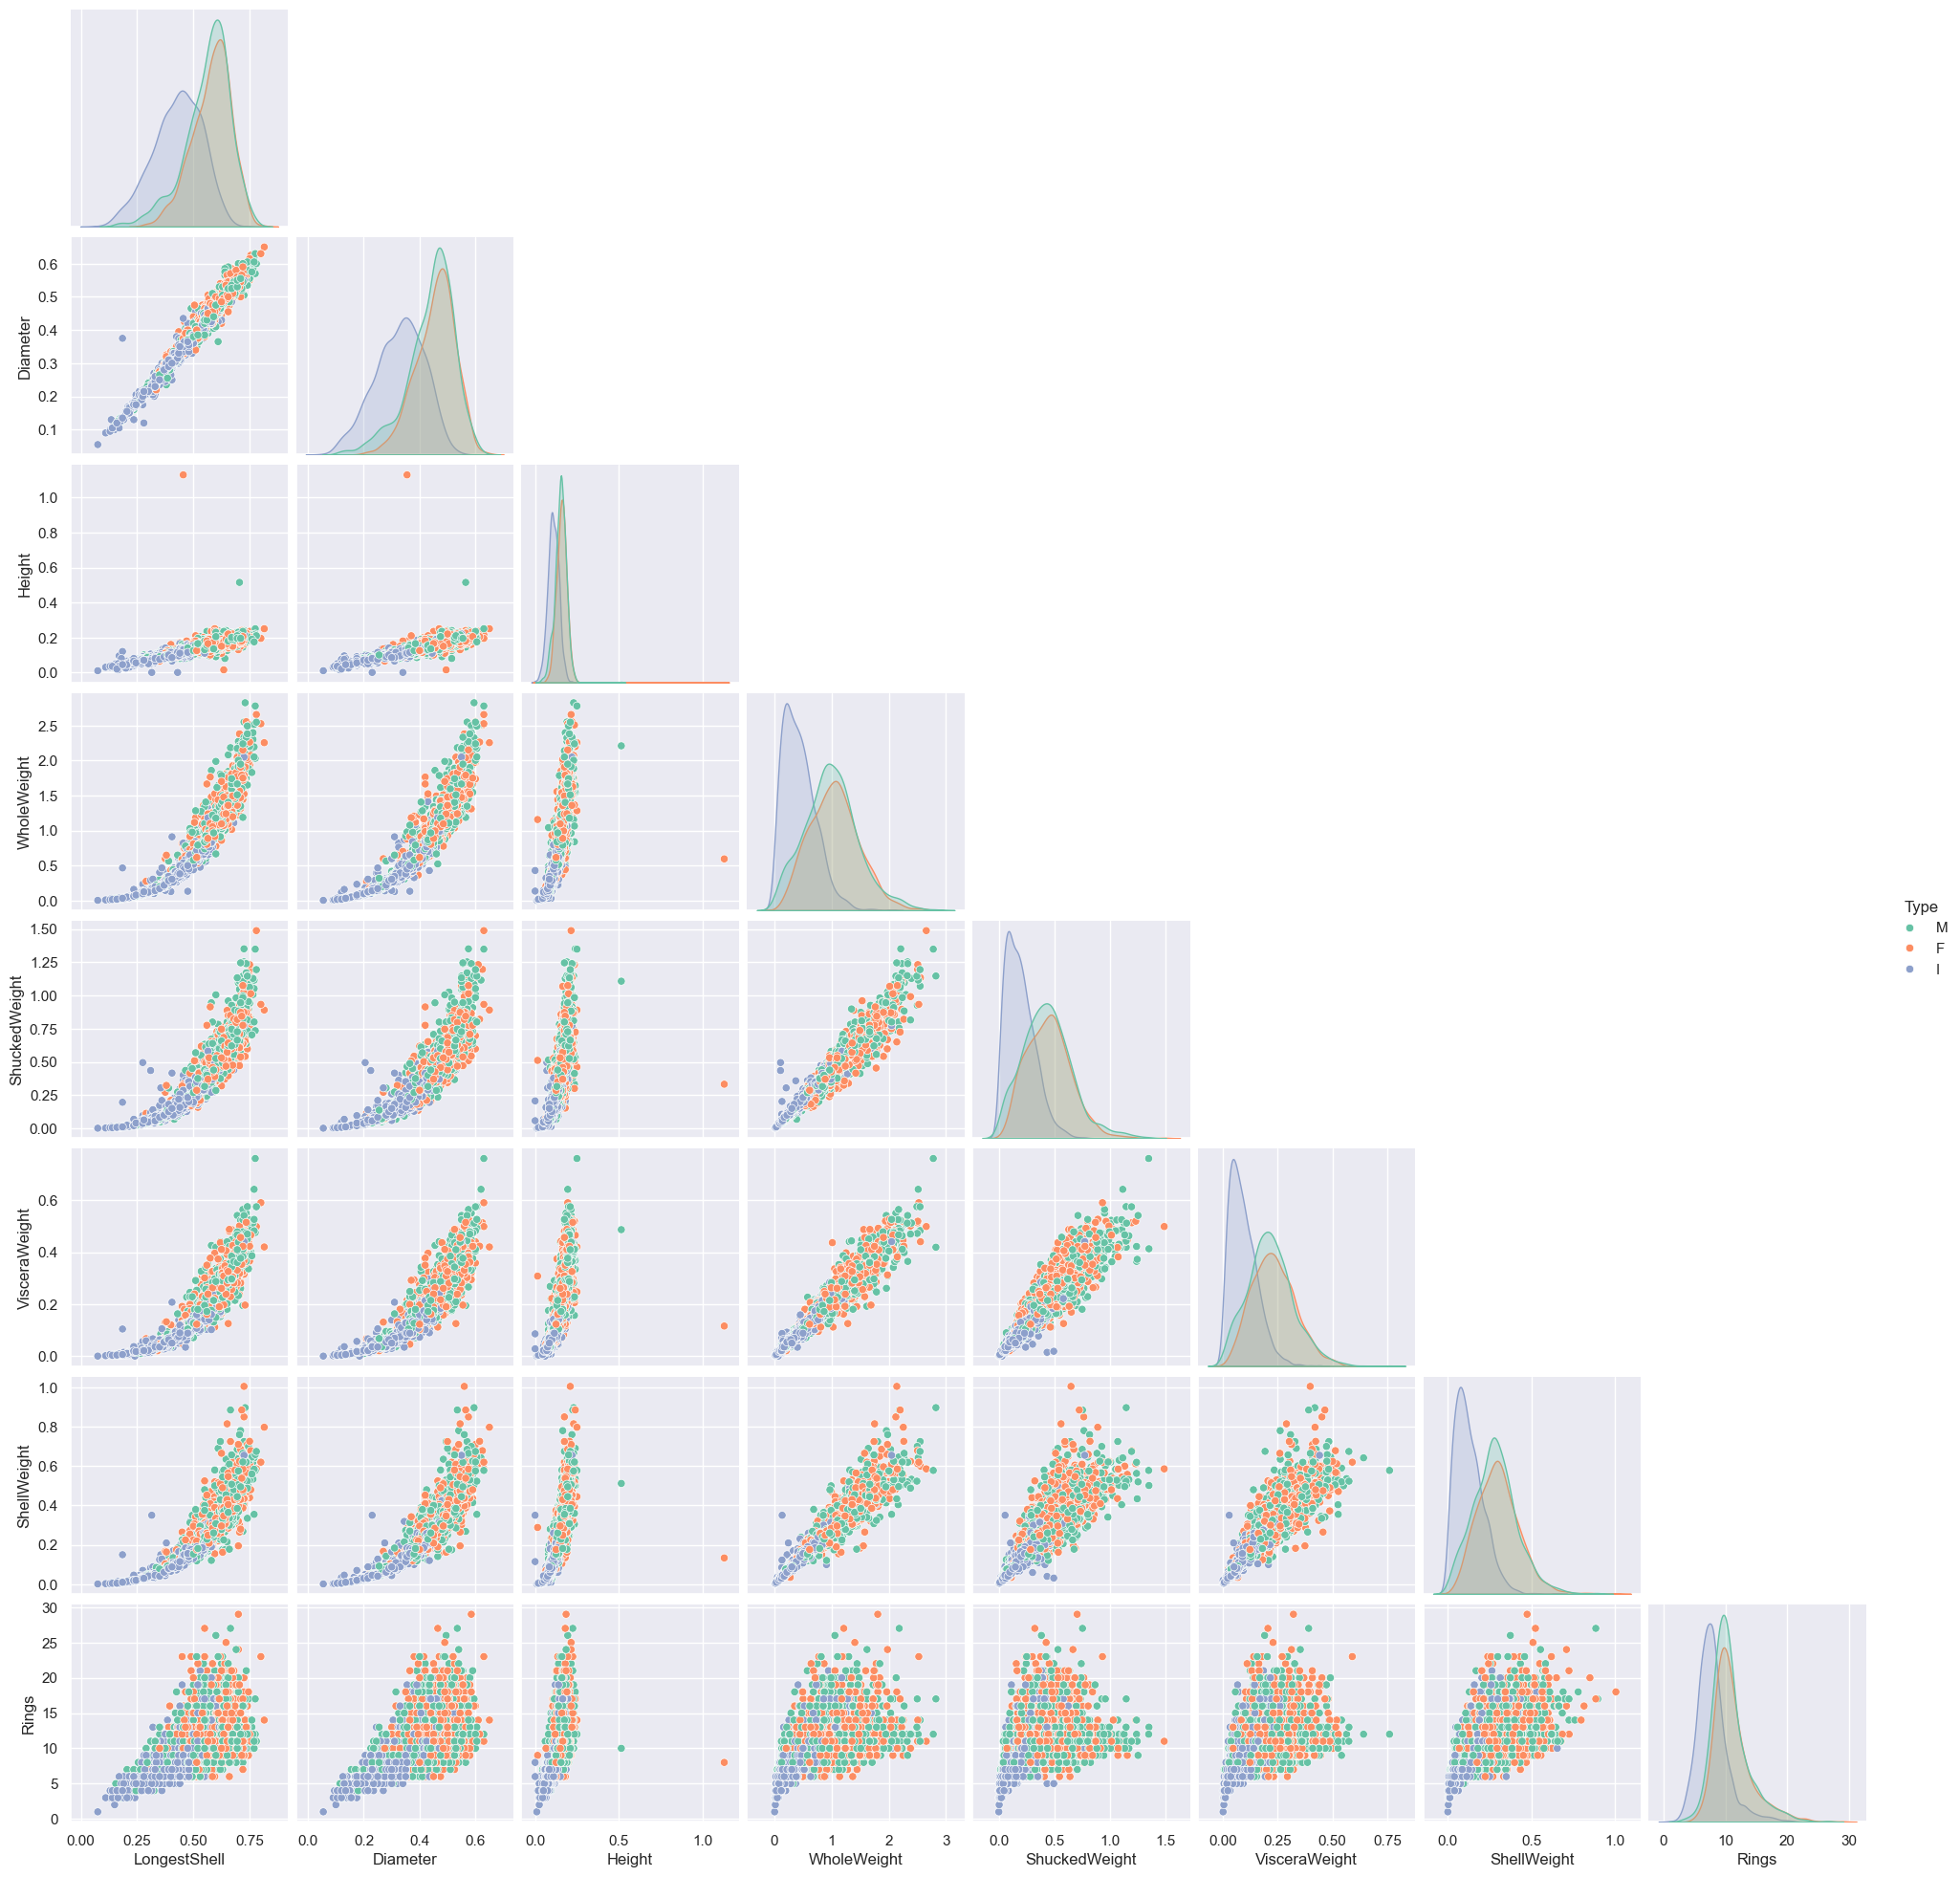

In [26]:
# Run first, I will thinking more about visualize
sns.set_theme()

sns.pairplot(data = abalone_df, hue = 'Type', corner = True,
             palette = 'Set2');

In [31]:
abalone_corr = abalone_df.corr(numeric_only = True)
abalone_corr

,LongestShell,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
LongestShell,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
WholeWeight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
ShuckedWeight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
VisceraWeight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
ShellWeight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


**Step to show heatmap**

TypeError: Axis.set_ticklabels() missing 1 required positional argument: 'labels'

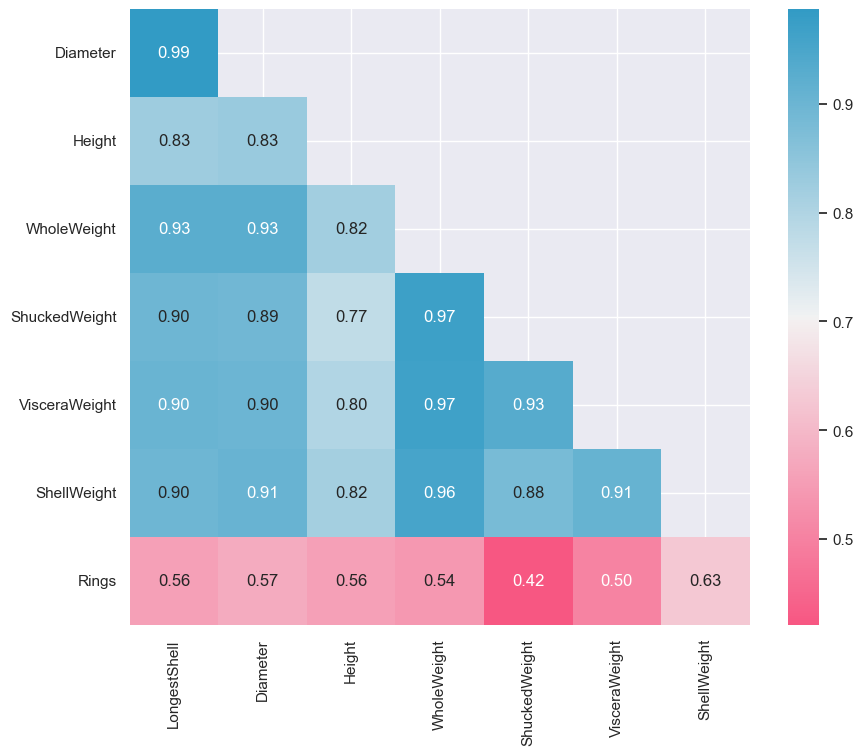

In [41]:
ones_corr = np.ones_like(abalone_corr, dtype = bool)
mask = np.triu(ones_corr)

adjusted_abalone = abalone_corr.iloc[1:, :-1]
adjusted_mask = mask[1:, :-1]

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap = True)

fig, ax = plt.subplots(figsize = (10, 8))

sns.heatmap(data = adjusted_abalone, mask = adjusted_mask, cmap = cmap,
            annot = True, fmt = '.2f');

